# 고가치 이탈 위험 고객의 쿠폰 타기팅 분석

목표는 `고가치 이탈 위험` 고객이 무엇을 샀는지 확인하고, 복귀를 유도할 개인별 카테고리·상품 쿠폰 후보를 만드는 것입니다.

분석 질문
1. 타깃 고객이 다른 고객보다 유독 선호하는 카테고리는 무엇인가?
2. 각 타깃 고객이 반복적으로 구매한 상위 카테고리는 무엇인가?
3. 해당 카테고리에서 쿠폰 이력이 있는 상품 중 어떤 상품을 후보로 제안할 수 있는가?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SEGMENT_PATH = PROJECT_DIR / "data" / "processed" / "customer_segments.csv"
TRANSACTION_PATH = PROJECT_DIR / "transaction_data.csv"
PRODUCT_PATH = PROJECT_DIR / "product.csv"
COUPON_PATH = PROJECT_DIR / "coupon.csv"
OUTPUT_DIR = PROJECT_DIR / "data" / "processed"
CUTOFF_DAY = 655

## 1. 타깃 고객과 거래 데이터 연결

In [2]:
segments = pd.read_csv(SEGMENT_PATH)
target_ids = set(segments.loc[segments["segment"] == "고가치 이탈 위험", "household_key"])

tx = pd.read_csv(
    TRANSACTION_PATH,
    usecols=["household_key","BASKET_ID","DAY","PRODUCT_ID","QUANTITY","SALES_VALUE"],
    dtype={"household_key":"int32", "BASKET_ID":"int64", "DAY":"int16",
           "PRODUCT_ID":"int32", "QUANTITY":"int32", "SALES_VALUE":"float32"},
)
tx = tx.loc[tx["DAY"] <= CUTOFF_DAY].copy()
products = pd.read_csv(PRODUCT_PATH, usecols=["PRODUCT_ID","DEPARTMENT","COMMODITY_DESC","SUB_COMMODITY_DESC","BRAND"])
tx = tx.merge(products, on="PRODUCT_ID", how="left", validate="many_to_one")
tx["is_target"] = tx["household_key"].isin(target_ids)
print(f"고가치 이탈 위험 고객: {len(target_ids):,}명")
print(f"기준일 이전 거래: {len(tx):,}행")
print(f"상품 정보 미연결: {tx['COMMODITY_DESC'].isna().sum():,}행")

고가치 이탈 위험 고객: 168명
기준일 이전 거래: 2,362,043행
상품 정보 미연결: 0행


## 2. 타깃 고객의 상대적 카테고리 선호도

`lift`는 타깃 고객의 구매 침투율을 나머지 고객의 구매 침투율로 나눈 값입니다. 1보다 크면 타깃 고객이 상대적으로 더 자주 구매한 카테고리입니다. 최소 10명의 타깃 고객이 산 카테고리만 해석합니다.

In [3]:
group_sizes = {True: len(target_ids), False: segments.loc[segments["segment"] != "고가치 이탈 위험", "household_key"].nunique()}
category_group = tx.groupby(["COMMODITY_DESC","is_target"]).agg(
    households=("household_key","nunique"), revenue=("SALES_VALUE","sum"),
    baskets=("BASKET_ID","nunique"), items=("QUANTITY","sum")
).reset_index()
category_group["group_customers"] = category_group["is_target"].map(group_sizes)
category_group["penetration"] = category_group["households"] / category_group["group_customers"]

wide = category_group.pivot(index="COMMODITY_DESC", columns="is_target", values=["households","revenue","penetration"]).fillna(0)
wide.columns = [f"{metric}_{'target' if group else 'other'}" for metric, group in wide.columns]
category_lift = wide.reset_index()
category_lift["lift"] = category_lift["penetration_target"] / category_lift["penetration_other"].replace(0, np.nan)
category_lift["target_revenue_per_customer"] = category_lift["revenue_target"] / len(target_ids)
category_lift["opportunity_score"] = category_lift["revenue_target"] * (category_lift["lift"] - 1).clip(lower=0)
category_lift = category_lift.query("households_target >= 10").sort_values("opportunity_score", ascending=False)
business_candidates = category_lift.query("households_target >= 20 and revenue_target >= 500")
business_candidates = business_candidates.loc[~business_candidates["COMMODITY_DESC"].str.contains("COUPON", case=False, na=False)]
display(business_candidates.head(20))

,COMMODITY_DESC,households_other,households_target,revenue_other,revenue_target,penetration_other,penetration_target,lift,target_revenue_per_customer,opportunity_score
58,CIGARETTES,871.0,104.0,71859.437500,17492.791016,0.373659,0.619048,1.656716,104.123756,11487.803055
26,BEERS/ALES,1435.0,134.0,116646.179688,19571.128906,0.615616,0.797619,1.295645,116.494815,5786.098563
81,DELI MEATS,1548.0,154.0,82842.750000,14378.059570,0.664093,0.916667,1.380329,85.583688,5468.399594
144,FUEL,289.0,40.0,21315.939453,5096.680176,0.123981,0.238095,1.920415,30.337382,4691.062030
25,BEEF,2049.0,165.0,246741.031250,38623.441406,0.879022,0.982143,1.117313,229.901437,4531.044279
48,CAT FOOD,637.0,84.0,25754.509766,4738.770020,0.273273,0.500000,1.829670,28.206964,3931.616884
152,HAIR CARE PRODUCTS,1315.0,149.0,33816.460938,6728.859863,0.564136,0.886905,1.572148,40.052737,3849.905658
54,CHICKEN,1690.0,161.0,74493.929688,11455.889648,0.725011,0.958333,1.321820,68.189819,3686.728984
53,CHEESES,1305.0,143.0,40847.699219,6582.649902,0.559846,0.851190,1.520402,39.182440,3425.626142
62,COFFEE,1396.0,144.0,50634.558594,7849.819824,0.598885,0.857143,1.431232,46.725118,3385.094222


/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_31881/1994536834.py:6: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_31881/1994536834.py:6: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_31881/1994536834.py:6: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_31881/1994536834.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vpsbzxn1tc0000gn/T/ipykernel_31881/1994536834.py:6: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/zs/4ytjwch171x696vp

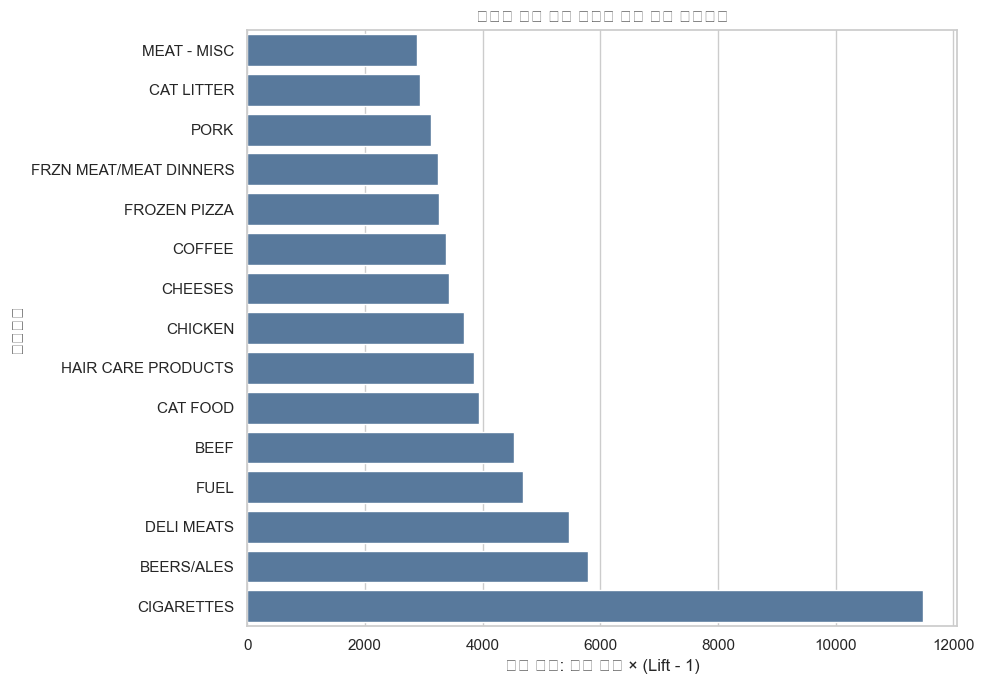

In [4]:
plot_lift = business_candidates.head(15).sort_values("opportunity_score")
plt.figure(figsize=(10,7))
sns.barplot(data=plot_lift, x="opportunity_score", y="COMMODITY_DESC", color="#4C78A8")
plt.title("고가치 이탈 위험 고객의 쿠폰 기회 카테고리")
plt.xlabel("기회 점수: 타깃 매출 × (Lift - 1)"); plt.ylabel("카테고리")
plt.tight_layout(); plt.show()

## 3. 개인별 상위 구매 카테고리

개인별 매출 비중을 기준으로 상위 3개 카테고리를 남깁니다. `category_revenue_share`가 높을수록 해당 고객에게 관련성이 높은 쿠폰 후보입니다.

In [5]:
target_tx = tx.loc[tx["is_target"]].copy()
personal_categories = target_tx.groupby(["household_key","COMMODITY_DESC"]).agg(
    category_revenue=("SALES_VALUE","sum"), category_baskets=("BASKET_ID","nunique"),
    category_items=("QUANTITY","sum"), last_category_day=("DAY","max")
).reset_index()
personal_categories["customer_revenue"] = personal_categories.groupby("household_key")["category_revenue"].transform("sum")
personal_categories["category_revenue_share"] = personal_categories["category_revenue"] / personal_categories["customer_revenue"]
personal_categories["category_recency"] = CUTOFF_DAY - personal_categories["last_category_day"]
personal_categories["category_rank"] = personal_categories.groupby("household_key")["category_revenue"].rank(method="first", ascending=False).astype(int)
personal_top_categories = personal_categories.query("category_rank <= 3").sort_values(["household_key","category_rank"])
display(personal_top_categories.head(12))

,household_key,COMMODITY_DESC,category_revenue,category_baskets,category_items,last_category_day,customer_revenue,category_revenue_share,category_recency,category_rank
33,17,COUPON/MISC ITEMS,697.229980,34,285008,552,5067.490234,0.137589,103,1
26,17,CIGARETTES,480.440002,5,18,139,5067.490234,0.094808,516,2
105,17,SOFT DRINKS,412.000000,42,120,640,5067.490234,0.081303,15,3
168,52,COUPON/MISC ITEMS,434.029999,10,171327,627,4751.680176,0.091342,28,1
158,52,COFFEE,314.859985,33,46,630,4751.680176,0.066263,25,2
282,52,SUSHI,184.599991,15,30,616,4751.680176,0.038849,39,3
445,68,SOFT DRINKS,555.429993,308,412,648,4622.459961,0.120159,7,1
346,68,COUPON/MISC ITEMS,450.200012,20,180907,650,4622.459961,0.097394,5,2
370,68,FLUID MILK PRODUCTS,220.330002,68,108,650,4622.459961,0.047665,5,3
514,72,COUPON/MISC ITEMS,371.739990,17,129880,619,6333.680176,0.058693,36,1


## 4. 쿠폰 상품 후보 연결

과거 `coupon.csv`에 등장한 상품 중 타깃 고객군에서 매출이 높았던 상품을 카테고리별 상위 3개 후보로 연결합니다. 이는 분석용 후보이며 실제 재발급 가능 여부와 할인율은 별도 정책 검토가 필요합니다.

In [6]:
coupons = pd.read_csv(COUPON_PATH).drop_duplicates()
coupon_products = coupons.groupby("PRODUCT_ID").agg(
    coupon_campaigns=("CAMPAIGN","nunique"), coupon_upcs=("COUPON_UPC","nunique")
).reset_index().merge(products, on="PRODUCT_ID", how="left")
target_product_sales = target_tx.groupby("PRODUCT_ID").agg(
    target_product_revenue=("SALES_VALUE","sum"), target_product_households=("household_key","nunique")
).reset_index()
eligible = coupon_products.merge(target_product_sales, on="PRODUCT_ID", how="inner")
eligible = eligible.sort_values(["COMMODITY_DESC","target_product_revenue"], ascending=[True,False])
eligible["product_rank_in_category"] = eligible.groupby("COMMODITY_DESC").cumcount() + 1
eligible = eligible.query("product_rank_in_category <= 3")
coupon_candidates = personal_top_categories.merge(eligible, on="COMMODITY_DESC", how="left")
coupon_candidates = coupon_candidates.sort_values(["household_key","category_rank","product_rank_in_category"])
display(coupon_candidates.head(15))

,household_key,COMMODITY_DESC,category_revenue,category_baskets,category_items,last_category_day,customer_revenue,category_revenue_share,category_recency,category_rank,PRODUCT_ID,coupon_campaigns,coupon_upcs,DEPARTMENT,BRAND,SUB_COMMODITY_DESC,target_product_revenue,target_product_households,product_rank_in_category
0,17,COUPON/MISC ITEMS,697.229980,34,285008,552,5067.490234,0.137589,103,1,1049788.0,2.0,2.0,MISC SALES TRAN,Private,MEAT SUPPLIES,540.859985,67.0,1.0
1,17,COUPON/MISC ITEMS,697.229980,34,285008,552,5067.490234,0.137589,103,1,882305.0,2.0,2.0,MISC SALES TRAN,Private,MISCELLANEOUS H & B AIDS,453.079987,51.0,2.0
2,17,COUPON/MISC ITEMS,697.229980,34,285008,552,5067.490234,0.137589,103,1,1042697.0,2.0,2.0,MISC SALES TRAN,Private,PRODUCE DEPT KEY RING,220.800003,55.0,3.0
3,17,CIGARETTES,480.440002,5,18,139,5067.490234,0.094808,516,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17,SOFT DRINKS,412.000000,42,120,640,5067.490234,0.081303,15,3,5569230.0,1.0,1.0,GROCERY,National,SOFT DRINKS 12/18&15PK CAN CAR,2391.229980,90.0,1.0
5,17,SOFT DRINKS,412.000000,42,120,640,5067.490234,0.081303,15,3,5569471.0,1.0,1.0,GROCERY,National,SOFT DRINKS 12/18&15PK CAN CAR,2110.909912,57.0,2.0
6,17,SOFT DRINKS,412.000000,42,120,640,5067.490234,0.081303,15,3,8090521.0,1.0,1.0,GROCERY,National,SOFT DRINKS 12/18&15PK CAN CAR,1453.290039,60.0,3.0
7,52,COUPON/MISC ITEMS,434.029999,10,171327,627,4751.680176,0.091342,28,1,1049788.0,2.0,2.0,MISC SALES TRAN,Private,MEAT SUPPLIES,540.859985,67.0,1.0
8,52,COUPON/MISC ITEMS,434.029999,10,171327,627,4751.680176,0.091342,28,1,882305.0,2.0,2.0,MISC SALES TRAN,Private,MISCELLANEOUS H & B AIDS,453.079987,51.0,2.0
9,52,COUPON/MISC ITEMS,434.029999,10,171327,627,4751.680176,0.091342,28,1,1042697.0,2.0,2.0,MISC SALES TRAN,Private,PRODUCE DEPT KEY RING,220.800003,55.0,3.0


## 5. 결과를 읽는 법

- `lift > 1`: 타깃 고객이 다른 고객보다 상대적으로 선호한 카테고리
- `households_target`: 일부 고객 한두 명의 특이 구매가 아닌지 확인하는 표본 수
- `category_revenue_share`: 개인에게 해당 카테고리가 얼마나 중요한지 나타내는 비중
- `category_recency`: 해당 카테고리를 마지막으로 산 후 지난 일수
- 쿠폰 후보는 선호도와 과거 쿠폰 이력을 연결한 가설이며 실제 효과는 캠페인 비교 분석으로 검증해야 함
- 담배·주류 등 규제 또는 책임 마케팅 대상 카테고리는 점수가 높아도 실제 추천 대상에서 제외하거나 별도 정책 검토가 필요함

In [7]:
category_lift.to_csv(OUTPUT_DIR / "segment_category_lift.csv", index=False, encoding="utf-8-sig")
personal_top_categories.to_csv(OUTPUT_DIR / "target_customer_top_categories.csv", index=False, encoding="utf-8-sig")
coupon_candidates.to_csv(OUTPUT_DIR / "coupon_target_candidates.csv", index=False, encoding="utf-8-sig")
print("저장 완료:")
print(OUTPUT_DIR / "segment_category_lift.csv")
print(OUTPUT_DIR / "target_customer_top_categories.csv")
print(OUTPUT_DIR / "coupon_target_candidates.csv")

저장 완료:
/Users/imsubeen/Desktop/YBIGTA/26-2/DA SUMMER2/data/processed/segment_category_lift.csv
/Users/imsubeen/Desktop/YBIGTA/26-2/DA SUMMER2/data/processed/target_customer_top_categories.csv
/Users/imsubeen/Desktop/YBIGTA/26-2/DA SUMMER2/data/processed/coupon_target_candidates.csv
